# 02 — Quantificação dos Insights

Este notebook complementa o `01_etl.ipynb`. Aqui ficam os cálculos que sustentam os números citados no README:
definição das métricas, satisfação por atraso, concentração geográfica, categorias e parcelamento.

Todos os resultados são calculados diretamente a partir de `data/raw/`.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

pd.set_option("display.float_format", "{:,.2f}".format)

RAW = Path("../data/raw")
IMG = Path("../imagens")

pedidos = pd.read_csv(
    RAW / "olist_orders_dataset.csv",
    parse_dates=[
        "order_purchase_timestamp",
        "order_delivered_customer_date",
        "order_estimated_delivery_date",
    ],
)
clientes = pd.read_csv(RAW / "olist_customers_dataset.csv")
itens = pd.read_csv(RAW / "olist_order_items_dataset.csv")
produtos = pd.read_csv(RAW / "olist_products_dataset.csv")
pagamentos = pd.read_csv(RAW / "olist_order_payments_dataset.csv")
avaliacoes = pd.read_csv(RAW / "olist_order_reviews_dataset.csv")

## 1. Período e definição das métricas

- **Faturamento**: soma de `payment_value` (valor pago pelo cliente, inclui frete e todos os status de pedido).
- **Ticket médio**: faturamento ÷ número de pedidos.
- **Clientes**: `customer_unique_id` distintos (o `customer_id` muda a cada pedido).
- **Entrega no prazo**: a **data** de entrega é menor ou igual à **data** estimada, comparando só o dia e ignorando a hora, entre os pedidos com as duas datas preenchidas. A data estimada não tem horário (é sempre 00:00), então um pedido entregue no próprio dia previsto está no prazo.

In [2]:
print("Primeira compra:", pedidos["order_purchase_timestamp"].min())
print("Última compra:  ", pedidos["order_purchase_timestamp"].max())

faturamento = pagamentos["payment_value"].sum()
n_pedidos = pedidos["order_id"].nunique()

cancelados = pedidos.loc[
    pedidos["order_status"].isin(["canceled", "unavailable"]), "order_id"
]
fat_cancelados = pagamentos.loc[
    pagamentos["order_id"].isin(cancelados), "payment_value"
].sum()

frete_share = itens["freight_value"].sum() / (
    itens["price"].sum() + itens["freight_value"].sum()
)

print(f"Faturamento: R$ {faturamento:,.2f}")
print(f"Pedidos: {n_pedidos:,}")
print(f"Ticket médio: R$ {faturamento / n_pedidos:,.2f}")
print(f"Clientes únicos: {clientes['customer_unique_id'].nunique():,}")
print(f"Pagamentos de pedidos cancelados/indisponíveis: R$ {fat_cancelados:,.2f}")
print(f"Participação do frete no valor dos itens: {frete_share:.1%}")

Primeira compra: 2016-09-04 21:15:19
Última compra:   2018-10-17 17:30:18
Faturamento: R$ 16,008,872.12
Pedidos: 99,441
Ticket médio: R$ 160.99
Clientes únicos: 96,096
Pagamentos de pedidos cancelados/indisponíveis: R$ 269,735.11
Participação do frete no valor dos itens: 14.2%


## 2. Satisfação: no prazo × com atraso

In [3]:
entregues = pedidos.dropna(
    subset=["order_delivered_customer_date", "order_estimated_delivery_date"]
).copy()

data_entrega = entregues["order_delivered_customer_date"].dt.normalize()
data_prevista = entregues["order_estimated_delivery_date"].dt.normalize()

entregues["dias_atraso"] = (data_entrega - data_prevista).dt.days
entregues["atrasado"] = entregues["dias_atraso"] > 0

print(f"Entregas no prazo: {1 - entregues['atrasado'].mean():.2%}")
print(f"Pedidos atrasados: {entregues['atrasado'].sum():,}")
print(f"Atraso médio dos atrasados: {entregues.loc[entregues['atrasado'], 'dias_atraso'].mean():.1f} dias")

base = entregues.merge(avaliacoes[["order_id", "review_score"]], on="order_id")
base["status_entrega"] = base["atrasado"].map({False: "No prazo", True: "Com atraso"})

resumo = base.groupby("status_entrega")["review_score"].agg(
    nota_media="mean",
    avaliacoes="count",
    pct_nota_1=lambda s: (s == 1).mean() * 100,
    pct_nota_4_5=lambda s: (s >= 4).mean() * 100,
)
resumo

Entregas no prazo: 93.23%
Pedidos atrasados: 6,535
Atraso médio dos atrasados: 10.6 dias


,nota_media,avaliacoes,pct_nota_1,pct_nota_4_5
status_entrega,,,,
Com atraso,2.27,6410,53.73,26.71
No prazo,4.29,89949,6.63,82.64


### Por que comparar só a data?

Se a comparação usasse data **e hora**, os pedidos entregues no próprio dia previsto (depois da meia-noite) seriam contados como atrasados. A célula abaixo mostra que esses pedidos têm nota média igual à dos pedidos no prazo, o que confirma que o critério por data é o correto.

In [4]:
mesmo_dia = base[
    (base["dias_atraso"] == 0)
    & (base["order_delivered_customer_date"] > base["order_estimated_delivery_date"])
]
print(f"Pedidos entregues no dia previsto, após 00:00: {mesmo_dia['order_id'].nunique():,}")
print(f"Nota média desses pedidos: {mesmo_dia['review_score'].mean():.2f}")

Pedidos entregues no dia previsto, após 00:00: 1,280
Nota média desses pedidos: 4.03


In [5]:
atrasados = base[base["atrasado"]].copy()
atrasados["faixa_atraso"] = pd.cut(
    atrasados["dias_atraso"],
    bins=[0, 3, 7, 14, 10_000],
    labels=["Até 3 dias", "4 a 7 dias", "8 a 14 dias", "15+ dias"],
)

nota_faixa = (
    atrasados.groupby("faixa_atraso", observed=True)["review_score"]
    .agg(nota_media="mean", avaliacoes="count")
)
nota_faixa

,nota_media,avaliacoes
faixa_atraso,,
Até 3 dias,3.29,1856
4 a 7 dias,2.10,1756
8 a 14 dias,1.68,1453
15+ dias,1.72,1345


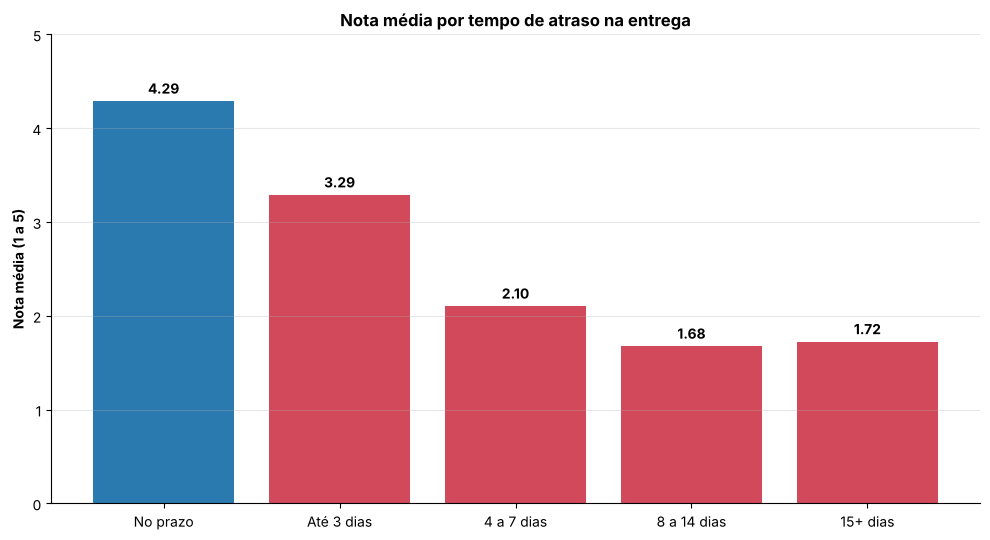

In [6]:
nota_no_prazo = resumo.loc["No prazo", "nota_media"]

rotulos = ["No prazo"] + list(nota_faixa.index.astype(str))
valores = [nota_no_prazo] + list(nota_faixa["nota_media"])
cores = ["#2a7ab0"] + ["#d1495b"] * len(nota_faixa)

fig, ax = plt.subplots(figsize=(10, 5.5))
barras = ax.bar(rotulos, valores, color=cores)
ax.bar_label(barras, fmt="%.2f", padding=3, fontweight="bold")

ax.set_title("Nota média por tempo de atraso na entrega", fontweight="bold")
ax.set_ylabel("Nota média (1 a 5)", fontweight="bold")
ax.set_ylim(0, 5)
ax.grid(axis="y", alpha=0.3)
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig(IMG / "nota_por_atraso.png", dpi=300, bbox_inches="tight")
plt.show()

## 3. Concentração geográfica

In [7]:
pedidos_clientes = pedidos.merge(clientes, on="customer_id")

clientes_estado = (
    pedidos_clientes.drop_duplicates("customer_unique_id")["customer_state"]
    .value_counts(normalize=True)
    .mul(100)
)

pagamentos_pedido = pagamentos.groupby("order_id", as_index=False)["payment_value"].sum()
fat_estado = (
    pagamentos_pedido.merge(pedidos_clientes[["order_id", "customer_state"]], on="order_id")
    .groupby("customer_state")["payment_value"].sum()
)
fat_estado = fat_estado / fat_estado.sum() * 100

geo = pd.DataFrame({"pct_clientes": clientes_estado, "pct_faturamento": fat_estado})
geo = geo.sort_values("pct_clientes", ascending=False)

print(f"SP + RJ + MG: {geo['pct_clientes'].head(3).sum():.1f}% dos clientes "
      f"e {geo['pct_faturamento'].head(3).sum():.1f}% do faturamento")
geo.head(5)

SP + RJ + MG: 66.5% dos clientes e 62.6% do faturamento


,pct_clientes,pct_faturamento
customer_state,,
SP,41.93,37.47
RJ,12.88,13.39
MG,11.71,11.70
RS,5.49,5.57
PR,5.08,5.07


In [8]:
atraso_estado = (
    entregues.merge(clientes, on="customer_id")
    .groupby("customer_state")
    .agg(pct_atraso=("atrasado", "mean"), pedidos=("order_id", "count"))
)
atraso_estado["pct_atraso"] *= 100

# Apenas estados com volume relevante (mais de 500 pedidos entregues)
atraso_estado.query("pedidos > 500").sort_values("pct_atraso", ascending=False).head(6)

,pct_atraso,pedidos
customer_state,,
MA,17.43,717
CE,13.76,1279
BA,12.16,3256
RJ,12.10,12353
PA,11.21,946
ES,10.73,1995


## 4. Categorias: volume × faturamento

In [9]:
cat = (
    itens.merge(produtos, on="product_id")
    .groupby("product_category_name")
    .agg(itens_vendidos=("order_item_id", "count"),
         faturamento=("price", "sum"),
         preco_medio=("price", "mean"))
)
cat["pct_faturamento"] = cat["faturamento"] / cat["faturamento"].sum() * 100

print("Top 5 por volume")
display(cat.sort_values("itens_vendidos", ascending=False).head(5))
print("Top 5 por faturamento")
display(cat.sort_values("faturamento", ascending=False).head(5))

Top 5 por volume


,itens_vendidos,faturamento,preco_medio,pct_faturamento
product_category_name,,,,
cama_mesa_banho,11115,"1,036,988.68",93.30,7.73
beleza_saude,9670,"1,258,681.34",130.16,9.38
esporte_lazer,8641,"988,048.97",114.34,7.37
moveis_decoracao,8334,"729,762.49",87.56,5.44
informatica_acessorios,7827,"911,954.32",116.51,6.80


Top 5 por faturamento


,itens_vendidos,faturamento,preco_medio,pct_faturamento
product_category_name,,,,
beleza_saude,9670,"1,258,681.34",130.16,9.38
relogios_presentes,5991,"1,205,005.68",201.14,8.98
cama_mesa_banho,11115,"1,036,988.68",93.30,7.73
esporte_lazer,8641,"988,048.97",114.34,7.37
informatica_acessorios,7827,"911,954.32",116.51,6.80


## 5. Parcelamento e valor da compra

In [10]:
faixas = pd.cut(
    pagamentos["payment_installments"],
    bins=[-1, 1, 5, 10, 100],
    labels=["1x", "2x a 5x", "6x a 10x", "Mais de 10x"],
)

parcelas = pagamentos.groupby(faixas, observed=True)["payment_value"].agg(
    valor_medio="mean", transacoes="count"
)
parcelas["pct_transacoes"] = parcelas["transacoes"] / parcelas["transacoes"].sum() * 100
parcelas

,valor_medio,transacoes,pct_transacoes
payment_installments,,,
1x,112.42,52548,50.58
2x a 5x,147.55,35211,33.89
6x a 10x,303.04,15786,15.20
Mais de 10x,358.34,341,0.33


## 6. Exportação das tabelas processadas

Atualiza os arquivos de `data/processed/` com o critério de prazo por data.

In [11]:
PROC = Path("../data/processed")

satisfacao = (
    base.groupby("status_entrega")["review_score"]
    .agg(Quantidade_Avaliacoes="count", Nota_Media="mean")
    .round(2)
    .reset_index()
    .rename(columns={"status_entrega": "Status_Entrega"})
)
satisfacao["Status_Entrega"] = satisfacao["Status_Entrega"].replace({"Com atraso": "Atrasada", "No prazo": "No Prazo"})
satisfacao.to_csv(PROC / "satisfacao_entrega.csv", index=False)

dist = (
    base.assign(Status_Entrega=base["atrasado"].map({True: "Atrasada", False: "No Prazo"}))
    .groupby(["Status_Entrega", "review_score"]).size().rename("Quantidade").reset_index()
)
dist["Percentual"] = (
    dist["Quantidade"] / dist.groupby("Status_Entrega")["Quantidade"].transform("sum") * 100
).round(2)
dist.to_csv(PROC / "distribuicao_notas_entrega.csv", index=False)

kpis = pd.DataFrame({
    "Indicador": ["Faturamento Total", "Total de Pedidos", "Ticket Médio", "Total de Clientes",
                  "Nota Média de Satisfação", "Frete Médio por Item", "Entregas no Prazo",
                  "Atraso Médio (dias)"],
    "Valor": [round(faturamento, 2), n_pedidos, round(faturamento / n_pedidos, 2),
              clientes["customer_unique_id"].nunique(), round(avaliacoes["review_score"].mean(), 2),
              round(itens["freight_value"].mean(), 2), round((1 - entregues["atrasado"].mean()) * 100, 2),
              round(entregues.loc[entregues["atrasado"], "dias_atraso"].mean(), 1)],
    "Unidade": ["R$", "Pedidos", "R$", "Clientes", "Nota de 1 a 5", "R$", "%", "Dias"],
})
kpis.to_csv(PROC / "resumo_kpis.csv", index=False, encoding="utf-8-sig")
kpis

,Indicador,Valor,Unidade
0,Faturamento Total,"16,008,872.12",R$
1,Total de Pedidos,"99,441.00",Pedidos
2,Ticket Médio,160.99,R$
3,Total de Clientes,"96,096.00",Clientes
4,Nota Média de Satisfação,4.09,Nota de 1 a 5
5,Frete Médio por Item,19.99,R$
6,Entregas no Prazo,93.23,%
7,Atraso Médio (dias),10.60,Dias


## 7. Conclusões

- Pedidos atrasados têm nota média **2 pontos menor** que os entregues no prazo (2,27 contra 4,29), e a nota cai conforme o atraso aumenta.
- **SP, RJ e MG** concentram cerca de dois terços dos clientes; MA, CE, BA e RJ têm as maiores taxas de atraso.
- As categorias que mais vendem em volume não são as que mais faturam: `relogios_presentes` tem preço médio alto e fica em 2º lugar no faturamento.
- Compras parceladas em 6x ou mais têm valor médio bem acima das compras à vista.